# 15 Extended model validation and calibration

Adds PR-AUC, Brier score, calibration curves, MCC, and decision curve analysis on the locked test set. This notebook is designed to follow notebooks 00-14 and does not use the test set for model selection.

BASE_DIR: /content
PROJECT_ROOT: /content/project_thermography_equine
OUTPUT_ROOT: /content/project_thermography_equine/outputs
Loaded /content/project_thermography_equine/outputs/config/cnn_model_predictions.csv shape=(347, 9)
Loaded /content/project_thermography_equine/outputs/config/classical_baseline_predictions.csv shape=(347, 8)


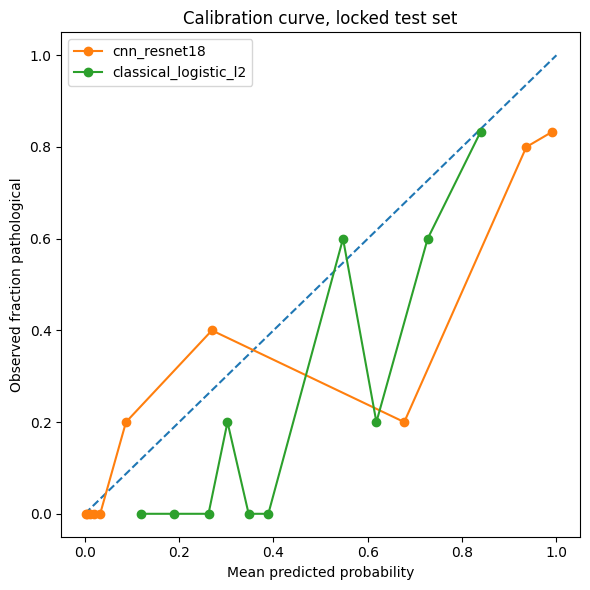

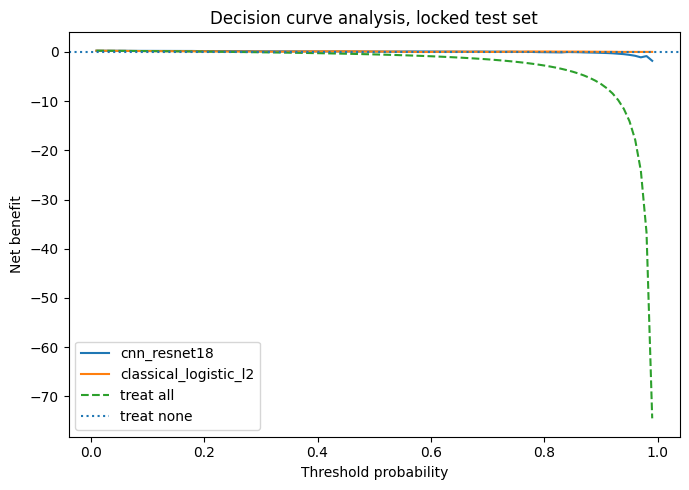

           model_name    analysis_set  n  n_positive  n_negative  threshold  roc_auc  average_precision_pr_auc  brier_score  matthews_correlation_coefficient  accuracy  balanced_accuracy  sensitivity_recall  specificity  precision_ppv      npv       f1  tn  fp  fn  tp
         cnn_resnet18 locked_test_set 53          13          40   0.500000 0.925000                  0.798452     0.115730                          0.580354  0.830189           0.809615            0.769231         0.85       0.625000 0.918919 0.689655  34   6   3  10
classical_logistic_l2 locked_test_set 53          13          40   0.212146 0.892308                  0.773189     0.144849                          0.274921  0.433962           0.625000            1.000000         0.25       0.302326 1.000000 0.464286  10  30   0  13


In [5]:
from pathlib import Path
import os, json, glob, shutil, warnings, math, random
from datetime import datetime, timezone
import numpy as np
import pandas as pd

SEED = int(os.environ.get("THERMO_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)

_candidate_bases = [Path(os.environ.get("THERMO_BASE_DIR", "")) if os.environ.get("THERMO_BASE_DIR") else None,
                    Path("/content"), Path("/mnt/data"), Path.cwd(), Path("/tmp")]
_candidate_bases = [p for p in _candidate_bases if p is not None]

def _base_is_usable(p):
    try:
        return p.exists() and os.access(p, os.W_OK)
    except Exception:
        return False

BASE_DIR = next((p for p in _candidate_bases if _base_is_usable(p)), Path("/tmp"))
PROJECT_NAME = os.environ.get("THERMO_PROJECT_NAME", "project_thermography_equine")
PROJECT_ROOT = BASE_DIR / PROJECT_NAME
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CONFIG_DIR = OUTPUT_ROOT / "config"
REPORTS_DIR = OUTPUT_ROOT / "reports"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
MODELS_DIR = OUTPUT_ROOT / "models"
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"
XAI_DIR = OUTPUT_ROOT / "xai_integrated_gradients"
for d in [PROJECT_ROOT, DATA_ROOT, OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, GRADCAM_DIR, XAI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEARCH_ROOTS = [PROJECT_ROOT, OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, GRADCAM_DIR, BASE_DIR, Path('/content'), Path('/mnt/data'), Path.cwd()]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    hits=[]
    for root in roots:
        root=Path(root)
        if not root.exists():
            continue
        for pat in patterns:
            hits.extend([p for p in root.rglob(pat) if p.is_file() and '.ipynb_checkpoints' not in p.parts])
    hits=sorted(set(hits), key=lambda p: p.stat().st_mtime, reverse=True)
    if required and not hits:
        raise FileNotFoundError(f"Could not find any of: {patterns}")
    return hits[0] if hits else None

def read_csv_found(patterns, required_cols=None, required=True):
    path=find_first(patterns, required=required)
    if path is None:
        return None, None
    df=pd.read_csv(path)
    if required_cols:
        missing=[c for c in required_cols if c not in df.columns]
        if missing:
            raise KeyError(f"{path} missing required columns: {missing}")
    print(f"Loaded {path} shape={df.shape}")
    return df, path

def save_text(path, text):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True); path.write_text(text, encoding='utf-8')

print('BASE_DIR:', BASE_DIR)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)

import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, matthews_corrcoef,
                             accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix,
                             precision_score, recall_score)
from sklearn.calibration import calibration_curve


cnn, cnn_path = read_csv_found(["cnn_model_predictions.csv", "*cnn*predictions*.csv"],
                               required_cols=["split", "label_binary", "cnn_probability_pathological"], required=False)
classical, classical_path = read_csv_found(["classical_baseline_predictions.csv", "*classical*predictions*.csv"],
                                           required_cols=["split", "label_binary", "classical_probability_pathological"], required=False)


if cnn is None or classical is None:
    review, review_path = read_csv_found(["error_case_review*.csv"],
        required_cols=["split", "label_binary", "cnn_probability_pathological", "classical_probability_pathological"], required=True)
    cnn = review.copy(); cnn_path = review_path
    classical = review.copy(); classical_path = review_path


cnn_test = cnn[cnn["split"].astype(str).str.lower().eq("test")].copy()
classical_test = classical[classical["split"].astype(str).str.lower().eq("test")].copy()
if cnn_test.empty:
    cnn_test = cnn.copy()
if classical_test.empty:
    classical_test = classical.copy()


def load_classical_threshold(default=0.5):
    p=find_first(["selected_classical_model.json"], required=False)
    if p:
        try:
            return float(json.loads(Path(p).read_text(encoding='utf-8')).get('decision_threshold', default))
        except Exception:
            return default
    return default

cnn_threshold = float(os.environ.get("THERMO_CNN_THRESHOLD", "0.5"))
classical_threshold = load_classical_threshold(default=float(os.environ.get("THERMO_CLASSICAL_THRESHOLD", "0.5")))

model_specs = [
    ("cnn_resnet18", cnn_test, "cnn_probability_pathological", "cnn_predicted_label_binary", cnn_threshold),
    ("classical_logistic_l2", classical_test, "classical_probability_pathological", "classical_predicted_label_binary", classical_threshold),
]

rows=[]
calibration_rows=[]
dca_rows=[]
thresholds=np.linspace(0.01,0.99,99)

def safe_metric(fn, *args, default=np.nan, **kwargs):
    try:
        return fn(*args, **kwargs)
    except Exception:
        return default

for model_name, df, prob_col, pred_col, threshold in model_specs:
    df=df.copy()
    df["label_binary"] = df["label_binary"].astype(int)
    df[prob_col] = pd.to_numeric(df[prob_col], errors='coerce')
    df = df.dropna(subset=[prob_col, "label_binary"])
    if pred_col in df.columns:
        y_pred = df[pred_col].astype(int).values
    else:
        y_pred = (df[prob_col].values >= threshold).astype(int)
    y_true = df["label_binary"].values.astype(int)
    y_prob = df[prob_col].values.astype(float)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    rows.append({
        "model_name": model_name,
        "analysis_set": "locked_test_set",
        "n": int(len(df)),
        "n_positive": int(y_true.sum()),
        "n_negative": int((1-y_true).sum()),
        "threshold": float(threshold),
        "roc_auc": safe_metric(roc_auc_score, y_true, y_prob),
        "average_precision_pr_auc": safe_metric(average_precision_score, y_true, y_prob),
        "brier_score": safe_metric(brier_score_loss, y_true, y_prob),
        "matthews_correlation_coefficient": safe_metric(matthews_corrcoef, y_true, y_pred),
        "accuracy": safe_metric(accuracy_score, y_true, y_pred),
        "balanced_accuracy": safe_metric(balanced_accuracy_score, y_true, y_pred),
        "sensitivity_recall": safe_metric(recall_score, y_true, y_pred),
        "specificity": tn/(tn+fp) if (tn+fp)>0 else np.nan,
        "precision_ppv": safe_metric(precision_score, y_true, y_pred, zero_division=0),
        "npv": tn/(tn+fn) if (tn+fn)>0 else np.nan,
        "f1": safe_metric(f1_score, y_true, y_pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    })

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=min(10, max(2, len(df)//5)), strategy="quantile")
    for i,(mp,fp_) in enumerate(zip(mean_pred, frac_pos), start=1):
        calibration_rows.append({"model_name": model_name, "bin": i, "mean_predicted_probability": mp, "observed_fraction_positive": fp_})
    # Decision curve analysis.
    prevalence = y_true.mean()
    for t in thresholds:
        pred_t = (y_prob >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, pred_t, labels=[0,1]).ravel()
        n=len(y_true)
        net_benefit = (tp_t/n) - (fp_t/n)*(t/(1-t))
        treat_all = prevalence - (1-prevalence)*(t/(1-t))
        dca_rows.append({"model_name": model_name, "threshold_probability": t, "net_benefit": net_benefit,
                         "treat_all_net_benefit": treat_all, "treat_none_net_benefit": 0.0})

extended = pd.DataFrame(rows)
calibration_df = pd.DataFrame(calibration_rows)
dca_df = pd.DataFrame(dca_rows)

for p in [CONFIG_DIR/"extended_model_validation_calibration.csv", REPORTS_DIR/"extended_model_validation_calibration.csv", TABLES_DIR/"table_extended_model_validation_calibration.csv"]:
    extended.to_csv(p, index=False)
for p in [CONFIG_DIR/"calibration_curve_data.csv", REPORTS_DIR/"calibration_curve_data.csv", TABLES_DIR/"table_calibration_curve_data.csv"]:
    calibration_df.to_csv(p, index=False)
for p in [CONFIG_DIR/"decision_curve_analysis.csv", REPORTS_DIR/"decision_curve_analysis.csv"]:
    dca_df.to_csv(p, index=False)

# Figures.
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], linestyle='--')
for model_name in calibration_df.model_name.unique():
    sub=calibration_df[calibration_df.model_name==model_name]
    plt.plot(sub["mean_predicted_probability"], sub["observed_fraction_positive"], marker='o', label=model_name)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction pathological")
plt.title("Calibration curve, locked test set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR/"calibration_curve_locked_test.png", dpi=300)
plt.show()

plt.figure(figsize=(7,5))
for model_name in dca_df.model_name.unique():
    sub=dca_df[dca_df.model_name==model_name]
    plt.plot(sub["threshold_probability"], sub["net_benefit"], label=model_name)
base=dca_df[dca_df.model_name==dca_df.model_name.iloc[0]]
plt.plot(base["threshold_probability"], base["treat_all_net_benefit"], linestyle='--', label='treat all')
plt.axhline(0, linestyle=':', label='treat none')
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("Decision curve analysis, locked test set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR/"decision_curve_analysis_locked_test.png", dpi=300)
plt.show()

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "analysis": "extended_model_validation_calibration",
    "inputs": {"cnn_predictions": str(cnn_path), "classical_predictions": str(classical_path)},
    "outputs": ["extended_model_validation_calibration.csv", "calibration_curve_data.csv", "decision_curve_analysis.csv"],
    "test_set_used_for_model_selection": False,
    "random_seed": SEED,
}
save_text(CONFIG_DIR/"extended_validation_diagnostics.json", json.dumps(summary, indent=2))
save_text(REPORTS_DIR/"methods_extended_model_validation_text.txt", "Extended validation was performed on the locked held-out test set. In addition to ROC-AUC, models were evaluated using average precision/PR-AUC, Brier score, calibration curves, Matthews correlation coefficient, and decision curve analysis. The locked test set was not used for model selection, threshold selection, calibration, or hyperparameter tuning.\n")
print(extended.to_string(index=False))


## Completion
Outputs are written to `outputs/config`, `outputs/reports`, `outputs/tables`, and `outputs/figures`.